# Análisis de Segmentación de Clientes - ConnectaTel
## Informe Analítico: Identificación de Segmentos de Mayor Valor

**Objetivo:** Identificar y caracterizar los segmentos de clientes más valiosos para ConnectaTel a través del análisis de patrones de uso y comportamiento.

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


Mounted at /content/drive


In [3]:
ruta = '/content/drive/MyDrive/df_conectatel_completo.csv'

users = pd.read_csv(ruta)
usage = pd.read_csv(ruta)

print(f" Usuarios: {users.shape[0]} registros")
print(f" Uso: {usage.shape[0]} registros")

# Mostrar estructura
print("\nEstructura Users")
print(f"Columnas: {list(users.columns)}")
print(f"Tipos de datos:\n{users.dtypes}")

print("\nEstructura Usage")
print(f"Columnas: {list(usage.columns)}")
print(f"Tipos de datos:\n{usage.dtypes}")

 Usuarios: 4000 registros
 Uso: 4000 registros

Estructura Users
Columnas: ['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan', 'churn_date', 'messages_included', 'gb_per_month', 'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute', 'total_calls', 'total_messages', 'total_minutes', 'total_length', 'status_usuario', 'total_usage']
Tipos de datos:
user_id                int64
first_name            object
last_name             object
age                  float64
city                  object
reg_date              object
plan                  object
churn_date           float64
messages_included      int64
gb_per_month           int64
minutes_included       int64
usd_monthly_pay        int64
usd_per_gb           float64
usd_per_message      float64
usd_per_minute       float64
total_calls          float64
total_messages       float64
total_minutes        float64
total_length         float64
status_usuario        object
total_usage    

In [4]:
# Preparación: Convertir fechas y ajustar nombres de columnas
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

# Renombrar columnas en el DataFrame 'users' para que coincidan con las expectativas de análisis posteriores
# y asignar a 'df' para su uso en las siguientes celdas.
df = users.rename(columns={
    'total_messages': 'total_texts',
    'total_minutes': 'total_call_minutes',
    'usd_monthly_pay': 'monthly_payment'
})

# Llenar valores NaN en columnas relacionadas con el uso con 0,
# ya que son de tipo float64 y pueden contener valores nulos.
df['total_calls'] = df['total_calls'].fillna(0)
df['total_texts'] = df['total_texts'].fillna(0)
df['total_call_minutes'] = df['total_call_minutes'].fillna(0)

print("Primeros registros del DataFrame procesado (df):")
print(df.head())

Primeros registros del DataFrame procesado (df):
   user_id first_name last_name   age      city                      reg_date  \
0    10000     Carlos    Garcia  38.0  Medellín 2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres  53.0         ? 2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez  57.0      CDMX 2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez  69.0    Bogotá 2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres  63.0       GDL 2022-01-02 02:17:11.657914478   

      plan churn_date  messages_included  gb_per_month  ...  monthly_payment  \
0   Basico        NaT                100             5  ...               12   
1   Basico        NaT                100             5  ...               12   
2   Basico        NaT                100             5  ...               12   
3  Premium        NaT                500            20  ...               25   
4   Basico        NaT                100             5  ...     

##Análisis Visual de Segmentos

### Gráfica 1: Cómo varía el consumo entre planes (Premium vs Básico)

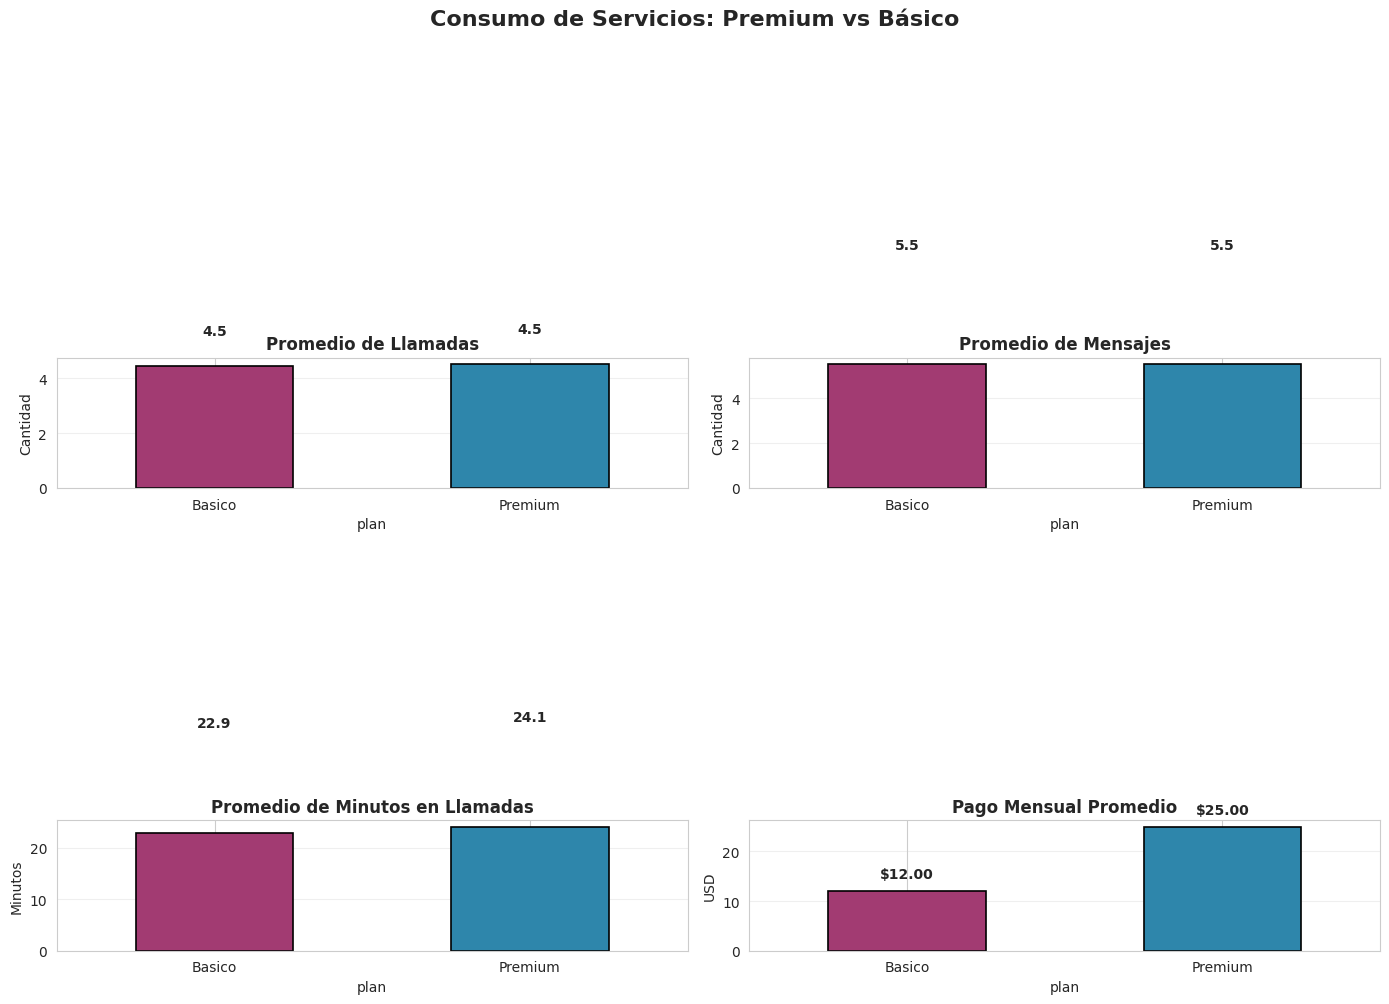

In [5]:
# Preparar datos de consumo por plan
consumption_by_plan = df.groupby('plan').agg({
    'total_calls': 'mean',
    'total_texts': 'mean',
    'total_call_minutes': 'mean',
    'monthly_payment': 'mean'
}).round(2)


# Gráfico de comparación
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Consumo de Servicios: Premium vs Básico', fontsize=16, fontweight='bold', y=1.00)

# Llamadas promedio
ax1 = axes[0, 0]
consumption_by_plan['total_calls'].plot(kind='bar', ax=ax1, color=['#A23B72', '#2E86AB'], edgecolor='black', linewidth=1.2)
ax1.set_title('Promedio de Llamadas', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cantidad', fontsize=10)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(consumption_by_plan['total_calls'].values):
    ax1.text(i, v + 1, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

# Mensajes promedio
ax2 = axes[0, 1]
consumption_by_plan['total_texts'].plot(kind='bar', ax=ax2, color=['#A23B72', '#2E86AB'], edgecolor='black', linewidth=1.2)
ax2.set_title('Promedio de Mensajes', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cantidad', fontsize=10)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(consumption_by_plan['total_texts'].values):
    ax2.text(i, v + 5, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

# Minutos de llamada
ax3 = axes[1, 0]
consumption_by_plan['total_call_minutes'].plot(kind='bar', ax=ax3, color=['#A23B72', '#2E86AB'], edgecolor='black', linewidth=1.2)
ax3.set_title('Promedio de Minutos en Llamadas', fontsize=12, fontweight='bold')
ax3.set_ylabel('Minutos', fontsize=10)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(consumption_by_plan['total_call_minutes'].values):
    ax3.text(i, v + 20, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

# Pago mensual
ax4 = axes[1, 1]
consumption_by_plan['monthly_payment'].plot(kind='bar', ax=ax4, color=['#A23B72', '#2E86AB'], edgecolor='black', linewidth=1.2)
ax4.set_title('Pago Mensual Promedio', fontsize=12, fontweight='bold')
ax4.set_ylabel('USD', fontsize=10)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.grid(axis='y', alpha=0.3)
for i, v in enumerate(consumption_by_plan['monthly_payment'].values):
    ax4.text(i, v + 2, f'${v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

#Interpretacion Grafica 1:
Los usuarios de ambos planes tienen niveles de consumo similares en cuanto a llamadas,mensajes y minutos de conversacion, la principal diferencia de estos planes es en el pago mensual porque los usuarios premium tienen un cobro mas caro por el servicio.

### Gráfica 2: Qué relación existe entre pago mensual y actividad de uso

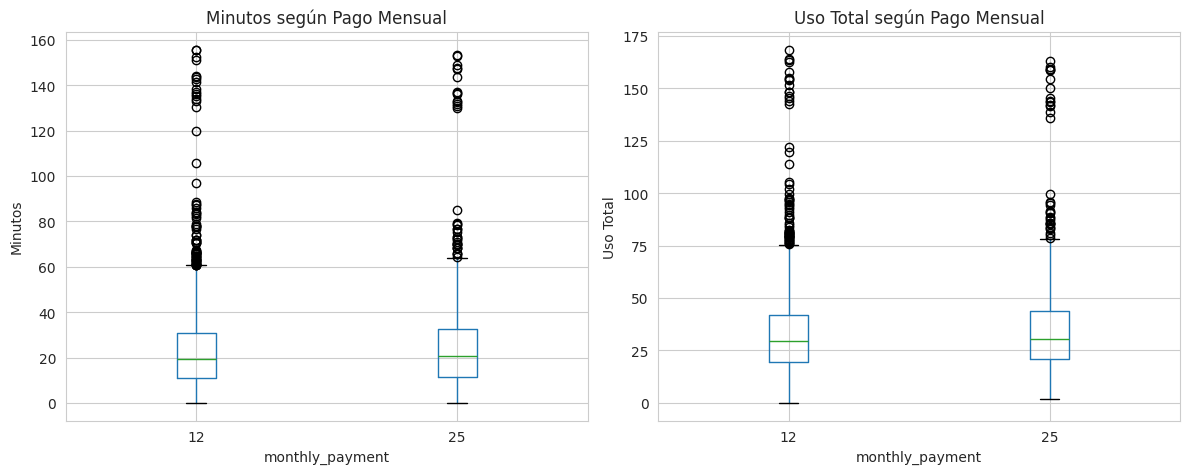

In [8]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

df.boxplot(column='total_call_minutes',
           by='monthly_payment',
           ax=axes[0])

axes[0].set_title('Minutos según Pago Mensual')
axes[0].set_ylabel('Minutos')

df.boxplot(column='total_usage',
           by='monthly_payment',
           ax=axes[1])

axes[1].set_title('Uso Total según Pago Mensual')
axes[1].set_ylabel('Uso Total')

plt.suptitle('')
plt.tight_layout()
plt.show()

#Interpretacion Grafica 2:
La disribucion de minutos y eventos es simlar entre los distintos niveles de pago mensual, lo que indica  es que asi se pague mas no necesariamente tendra mayor actividad o por pagar mas se utilizaran mas servicios.

### Gráfica 3: Cómo influye la edad en el consumo de servicios

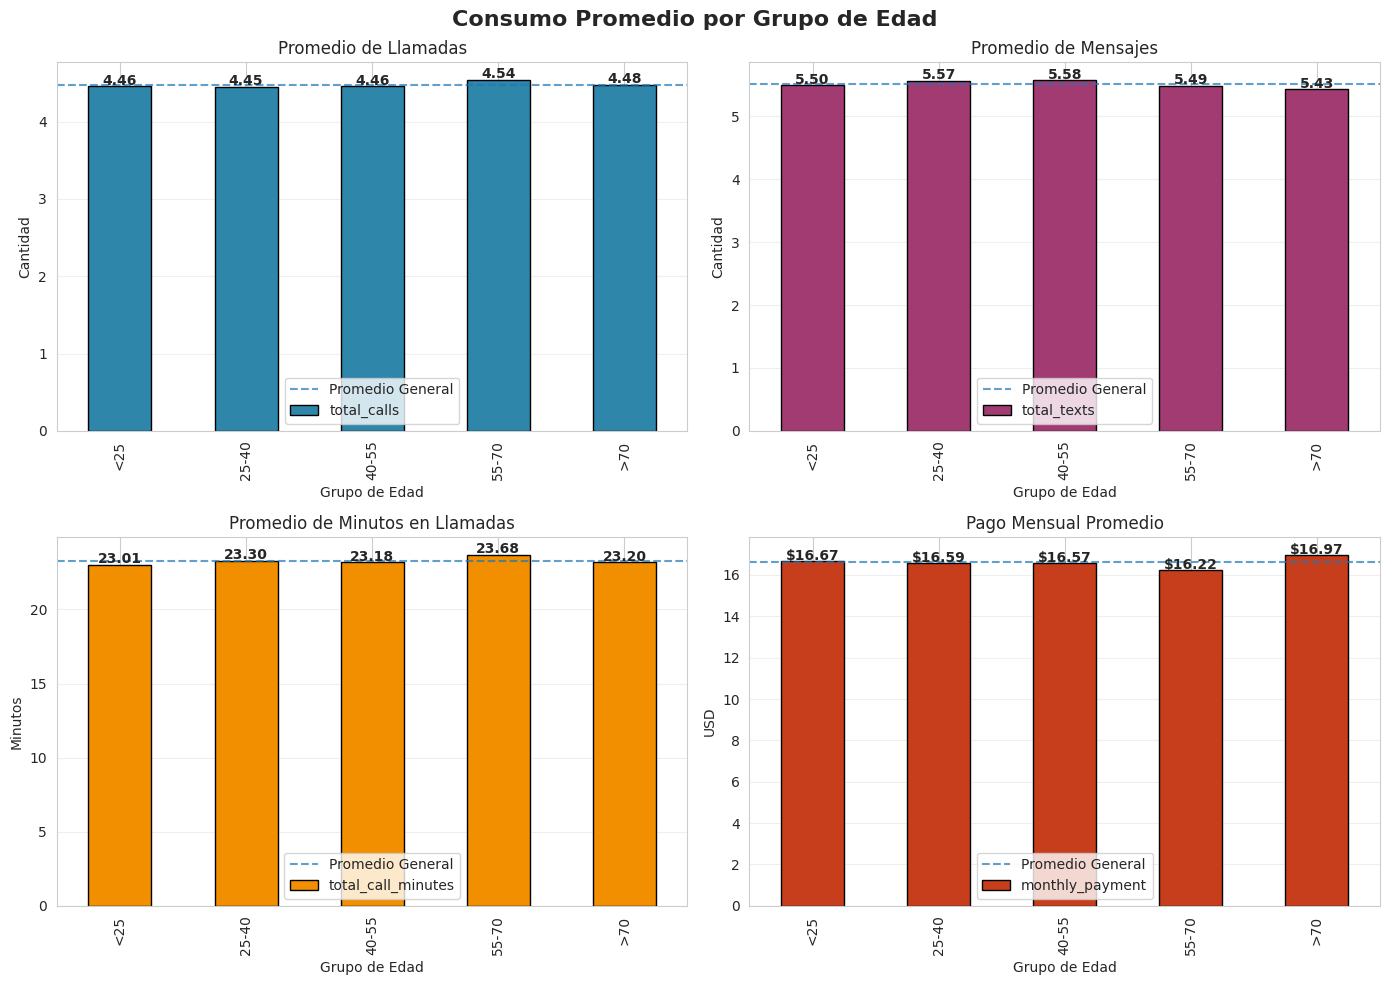

In [10]:
# Create age groups
bins = [0, 25, 40, 55, 70, np.inf]
labels = ['<25', '25-40', '40-55', '55-70', '>70']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Calculate consumption by age group
consumption_by_age = df.groupby('age_group').agg({
    'total_calls': 'mean',
    'total_texts': 'mean',
    'total_call_minutes': 'mean',
    'monthly_payment': 'mean'
}).round(2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    'Consumo Promedio por Grupo de Edad',
    fontsize=16,
    fontweight='bold'
)


ax1 = axes[0, 0]

consumption_by_age['total_calls'].plot(
    kind='bar',
    ax=ax1,
    color='#2E86AB',
    edgecolor='black'
)

ax1.set_title('Promedio de Llamadas')
ax1.set_ylabel('Cantidad')
ax1.set_xlabel('Grupo de Edad')
ax1.grid(axis='y', alpha=0.3)

ax1.axhline(
    consumption_by_age['total_calls'].mean(),
    linestyle='--',
    alpha=0.7,
    label='Promedio General'
)

for i, v in enumerate(consumption_by_age['total_calls']):
    ax1.text(i, v + 0.02, f'{v:.2f}',
             ha='center',
             fontweight='bold')

ax1.legend()


ax2 = axes[0, 1]

consumption_by_age['total_texts'].plot(
    kind='bar',
    ax=ax2,
    color='#A23B72',
    edgecolor='black'
)

ax2.set_title('Promedio de Mensajes')
ax2.set_ylabel('Cantidad')
ax2.set_xlabel('Grupo de Edad')
ax2.grid(axis='y', alpha=0.3)

ax2.axhline(
    consumption_by_age['total_texts'].mean(),
    linestyle='--',
    alpha=0.7,
    label='Promedio General'
)

for i, v in enumerate(consumption_by_age['total_texts']):
    ax2.text(i, v + 0.02, f'{v:.2f}',
             ha='center',
             fontweight='bold')

ax2.legend()


ax3 = axes[1, 0]

consumption_by_age['total_call_minutes'].plot(
    kind='bar',
    ax=ax3,
    color='#F18F01',
    edgecolor='black'
)

ax3.set_title('Promedio de Minutos en Llamadas')
ax3.set_ylabel('Minutos')
ax3.set_xlabel('Grupo de Edad')
ax3.grid(axis='y', alpha=0.3)

ax3.axhline(
    consumption_by_age['total_call_minutes'].mean(),
    linestyle='--',
    alpha=0.7,
    label='Promedio General'
)

for i, v in enumerate(consumption_by_age['total_call_minutes']):
    ax3.text(i, v + 0.1, f'{v:.2f}',
             ha='center',
             fontweight='bold')

ax3.legend()

ax4 = axes[1, 1]

consumption_by_age['monthly_payment'].plot(
    kind='bar',
    ax=ax4,
    color='#C73E1D',
    edgecolor='black'
)

ax4.set_title('Pago Mensual Promedio')
ax4.set_ylabel('USD')
ax4.set_xlabel('Grupo de Edad')
ax4.grid(axis='y', alpha=0.3)

ax4.axhline(
    consumption_by_age['monthly_payment'].mean(),
    linestyle='--',
    alpha=0.7,
    label='Promedio General'
)

for i, v in enumerate(consumption_by_age['monthly_payment']):
    ax4.text(i, v + 0.05, f'${v:.2f}',
             ha='center',
             fontweight='bold')

ax4.legend()

plt.tight_layout()
plt.show()

#Interpretacion Grafica 3:
Al revisar la grafica se observa que realmente no hay mucha diferencia entre los promedios, el consumo de todos es similiar, por lo que la edad no ejerce una influencia significativa sobre el uso de los servicios al ser analizados.

### Gráfica 4: Distribución de Ingresos Mensuales


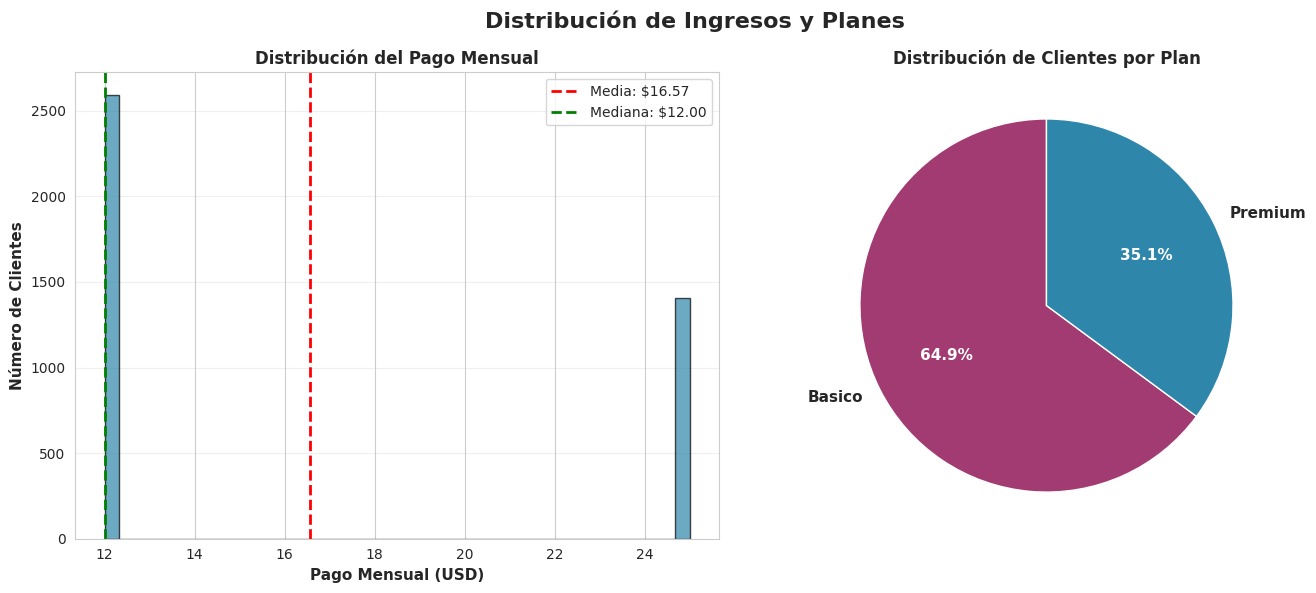

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribución de Ingresos y Planes', fontsize=16, fontweight='bold')

# Histograma de pago mensual
ax1 = axes[0]
payment_data = df[df['monthly_payment'] > 0]['monthly_payment']
ax1.hist(payment_data, bins=40, color='#2E86AB', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Pago Mensual (USD)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Número de Clientes', fontsize=11, fontweight='bold')
ax1.set_title('Distribución del Pago Mensual', fontsize=12, fontweight='bold')
ax1.axvline(payment_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${payment_data.mean():.2f}')
ax1.axvline(payment_data.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: ${payment_data.median():.2f}')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Pie chart de distribución por plan
ax2 = axes[1]
plan_counts = df['plan'].value_counts()
colors = ['#A23B72', '#2E86AB']
wedges, texts, autotexts = ax2.pie(plan_counts.values, labels=plan_counts.index, autopct='%1.1f%%',
                                     colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Distribución de Clientes por Plan', fontsize=12, fontweight='bold')

# Mejorar etiquetas
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)

plt.tight_layout()
plt.show()

#Interpretacion Grafica 4:

Al validar la distribucion de los pagos se refleja que la existencia de distintos niveles de tarifas en los planes disponibles, la distribucion de los clientes por planes identifican que tan equilibrada esta la base de usuarios entre las opciones de suscripcion

##INFORME NARRATIVO: Segmentación de Clientes ConnectaTel

# ¿Qué segmentos de clientes son más valiosos para ConnectaTel y qué patrones de uso los caracterizan?

Al validar los datos de la empresa ConnectaTel se logra obrservar que no todos los clientes aportan el mismo valor a la compañia, por lo que para identificar las diferencias entre estos grupos, se decide clasificarlos en cuatro segmentos

1.   Bajo Valor
2.   Valor Medio
1.   Alto Valor
2.   Clientes de alto valor operativo

Cada uno de estos esta compuesto por 1000 clientes ya que el total de clientes son 4000 analizados, al segmentarlos de esta manera permite entender que tipo de clientes utilizan mas los servicios y cuales de estos representan una mayor importancia para la empresa.

Se hace de esa forma ya que todos los usuarios no usan el servicio de forma permanente si no ocasional y otro todos los dias, por lo que los que son mas valiosos entre en el grupo de alto valor operativo ya que estos realizan mas llamadas, envian mas mensajes y generan mas interaccion con los servicios de la compañia, por el contrario los del segmente de bajo valor son usuarios que nunca o casi nunca usan los servicios, ahora si entramos en hallazgos interesantes en el ejercicio es por ejemplo las variables de la edad ya que se creeria que la edad infiere a la hora del uso de lo servicios,pero curiosamente no, en el analisis el promedio del consumo de llamadas 4.5 ,mensajes tiene promedios muy parecidos cercanos a las 5.5 y el promedio de conversacion alrededor de 23min por lo que los clientes jovenes,adultos y ancianos utilizan los servicios de la compañoa de una forma similar y no aporta mucha informacion acerca del valor de cada usuario.

Al revisar los planes que tenemos en la compañia nos encontramos con dos planes el basico y el premium en el cual hay una diferencia del doble entre cada uno, el basico estando alrededor de 12 USD y el premium con 25USD, se tendria a pensar que los clientes con el plan mas costoso usan mas servicio debido a que pagan mas por el y si,pero no sigficativamente diferenciado del plan basico,se podria decir que un usuario de plan basico puede sobrevivir con el y un usuario premium por economia le convendria mejor el basico, si nos vamos a los datos, el plan basico genero en promedio 4.45 llamdas,5.53 mensajes y 22.60min de conversacion mientras que el premium genera 4.52 llamadas,5.52 mensajes y 24.08 minutos no hay demasiada diferencia,el usuario que paga el plan premium lo hace porque tal vez desea tener mayor limite disponible o beneficios adicionales, pero facilmente puede sobrevivir con un basico.

En otras palabras, pagar mas no garantiza que una persona utilice mas los servicios, los clientes con pagos altos tienen niveles de actividad comparales a usuarios que pagan mucho menos, este valor indica que el valor economico no siempre coincide con el nivel real de interaccion con la compañia.

Desde una perspectiva de negocio la compañia deeria centrarse en que los clientes del plan basico contraten un premium ofreciendole mas beneficios y retener a los del plan premium ofreciendoles beneficios o promociones adicionales, o creando un solo plan intermedio en el cual se segmente mejor los servicios y halla mejor cobro con las mismas condiciones,cualquier estrategia que se use se debe de usar para mejorar la retencion o fortalecer la relacion de cliente con la compañia.



## Reflexión Personal

La asignatura y el tema me parecio bastante interesante, jugar con los datos y las estadisticas siempre es un buen conocimiento,como se puede usar python,pandas y numpy para desarrollar los ejercicios me parece bueno, en muchos trabajos de la industria es uno de los requisitos junto a SQL y Powerbi para entrar a cargos junior de analisis de datos como por ejemplo studio F, entonces es un conocimiento que se aprovecha, en cuanto al trabajo de la docente me parece que se prepara bien para las clases y son entretenidas y se aprendia, solo como consejo de mejora diria no darle mucha atencion a algunos estudiantes porque se volvia canson por momentos la intervenciones repetidas de alguno de ellos.